# Spectrogram Generation
create a spectrogram for a givem audio

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_from_disk
from pathlib import Path

In [7]:
# Load the audio file
audio_file = r"C:\Users\Dhanuja\Desktop\CyberSecLecNotes\Lime_-_Bon_Jovi_-_Livin_On_A_Prayer_(mp3.pm)_instrum (1).flac"
y, sr = librosa.load(audio_file)

In [8]:
# Generate the spectrogram
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

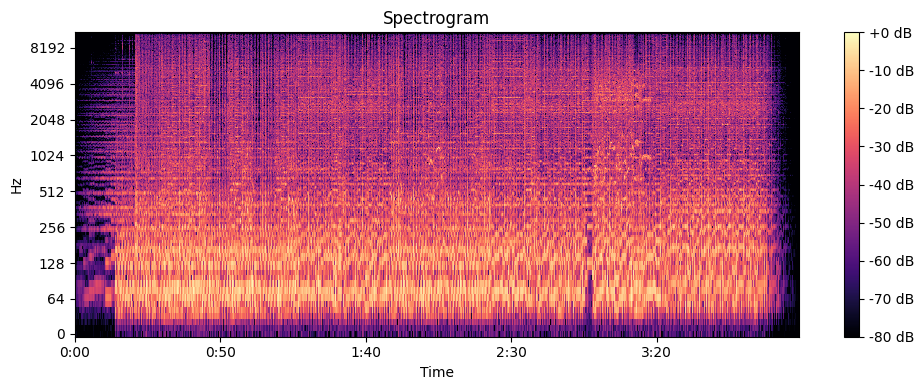

In [9]:
# Display the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

# Multi Spectogram Generation
Install Jupyter Notebook and set up the environment for creating notebooks.

In [8]:
import os

def generate_spectrograms(folder_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        if os.path.isfile(file_path):
            # Assuming all files are audio files; add checks if needed
            y, sr = librosa.load(file_path)
            D = librosa.stft(y)
            S_db = librosa.amplitude_to_db(abs(D), ref=np.max)
            
            plt.figure(figsize=(10, 4))
            librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
            plt.colorbar(format='%+2.0f dB')
            plt.title('Spectrogram')
            plt.tight_layout()
            
            # Save the spectrogram as an image
            output_file = os.path.join(output_folder, os.path.splitext(file_name)[0] + '.png')
            plt.savefig(output_file)
            plt.close()



In [9]:
# Example usage:
generate_spectrograms(r'C:\Users\Dhanuja\Desktop\CyberSecLecNotes\test\input', r'C:\Users\Dhanuja\Desktop\CyberSecLecNotes\test\output')

# Download rock data


In [14]:
def load_rock_dataset(dataset_path="../data/rock_dataset"):
    """Load filtered rock dataset"""
    path = Path(dataset_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found. Run raw_dataloader.py first."
        )
    return load_from_disk(str(path))

In [15]:
dataset = load_rock_dataset()
print(f"Loaded {len(dataset)} rock songs\n")

Loaded 872 rock songs



In [16]:
import soundfile as sf
from pathlib import Path

def download_audio_files(dataset, output_dir):
    """Download audio files from dataset to specified directory"""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    for i, example in enumerate(dataset):
        audio = example['audio']
        y = audio['array']
        sr = audio['sampling_rate']
        
        # Use track_id if available, otherwise index
        track_id = example.get('track_id', f"{i:05d}")
        filename = f"{track_id}.wav"
        
        sf.write(output_path / filename, y, sr)
        if i % 100 == 0:
            print(f"Downloaded {i+1} files...")
    
    print(f"✓ Downloaded {len(dataset)} audio files to {output_dir}")



In [17]:
# Example usage - download to a specific location
download_audio_files(dataset, "../data/rock_audio_files")

Downloaded 1 files...
Downloaded 101 files...
Downloaded 201 files...
Downloaded 301 files...
Downloaded 401 files...
Downloaded 501 files...
Downloaded 601 files...
Downloaded 701 files...
Downloaded 801 files...
✓ Downloaded 872 audio files to ../data/rock_audio_files


# Download non rock data


In [11]:
def load_non_rock_dataset(dataset_path="../data/nonrock_dataset"):
    """Load filtered non-rock dataset"""
    path = Path(dataset_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found. Run raw_dataloader.py first."
        )
    return load_from_disk(str(path))

In [12]:
from pathlib import Path

dataset = load_non_rock_dataset()
print(f"Loaded {len(dataset)} non-rock songs\n")

Loaded 911 non-rock songs



In [13]:
import soundfile as sf
from pathlib import Path

def download_audio_files(dataset, output_dir):
    """Download audio files from dataset to specified directory"""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    for i, example in enumerate(dataset):
        audio = example['audio']
        y = audio['array']
        sr = audio['sampling_rate']
        
        # Use track_id if available, otherwise index
        track_id = example.get('track_id', f"{i:05d}")
        filename = f"{track_id}.wav"
        
        sf.write(output_path / filename, y, sr)
        if i % 100 == 0:
            print(f"Downloaded {i+1} files...")
    
    print(f"✓ Downloaded {len(dataset)} audio files to {output_dir}")

In [14]:
# Example usage - download to a specific location
download_audio_files(dataset, "../data/nonrock_audio_files")

Downloaded 1 files...
Downloaded 101 files...
Downloaded 201 files...
Downloaded 301 files...
Downloaded 401 files...
Downloaded 501 files...
Downloaded 601 files...
Downloaded 701 files...
Downloaded 801 files...
Downloaded 901 files...
✓ Downloaded 911 audio files to ../data/nonrock_audio_files


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imsparsh/lakh-midi-clean")

print("Path to dataset files:", path)

100%|██████████| 226M/226M [00:22<00:00, 10.5MB/s] 

Extracting files...


Path to dataset files: C:\Users\Dhanuja\.cache\kagglehub\datasets\imsparsh\lakh-midi-clean\versions\1


In [ ]:
import os

# List MIDI files in the downloaded dataset
midi_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.mid') or f.endswith('.midi')]
print(f"Found {len(midi_files)} MIDI files in the dataset")
print("Sample files:", midi_files[:5])